In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries loaded successfully")

Matplotlib is building the font cache; this may take a moment.


All libraries loaded successfully


In [2]:
df = pd.read_csv('AB_NYC_2019.csv')

print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (48895, 16)

First 5 rows:


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [3]:
print("Column names and data types:")
print(df.dtypes)
print("\nMissing values per column:")
print(df.isnull().sum())

Column names and data types:
id                                  int64
name                               object
host_id                             int64
host_name                          object
neighbourhood_group                object
neighbourhood                      object
latitude                          float64
longitude                         float64
room_type                          object
price                               int64
minimum_nights                      int64
number_of_reviews                   int64
last_review                        object
reviews_per_month                 float64
calculated_host_listings_count      int64
availability_365                    int64
dtype: object

Missing values per column:
id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude         

In [4]:
# Fill missing review values with 0
df['reviews_per_month'] = df['reviews_per_month'].fillna(0)

# Fill missing name and host_name with 'Unknown'
df['name'] = df['name'].fillna('Unknown')
df['host_name'] = df['host_name'].fillna('Unknown')

# Remove extreme price outliers - listings above $1500/night
df = df[df['price'] > 0]
df = df[df['price'] <= 1500]

print("After cleaning:", df.shape)
print("Price range: $", df['price'].min(), "to $", df['price'].max())

After cleaning: (48745, 16)
Price range: $ 10 to $ 1500


In [5]:
# Feature 1: availability percentage
df['availability_pct'] = (df['availability_365'] / 365 * 100).round(2)

# Feature 2: price per minimum nights
df['price_per_min_nights'] = (df['price'] * df['minimum_nights']).round(2)

# Feature 3: review score bin
df['review_score_bin'] = pd.cut(
    df['reviews_per_month'],
    bins=[-1, 0, 1, 3, float('inf')],
    labels=['No reviews', 'Low', 'Medium', 'High']
)

print("New features added:")
print(df[['availability_pct', 'price_per_min_nights', 'review_score_bin']].head())

New features added:
   availability_pct  price_per_min_nights review_score_bin
0            100.00                   149              Low
1             97.26                   225              Low
2            100.00                   450       No reviews
3             53.15                    89             High
4              0.00                   800              Low


/var/folders/17/zk_2gn5n5yl5y3873zlymd6h0000gn/T/ipykernel_3628/3269489147.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=borough_price.index, y=borough_price.values, palette='Blues_d')


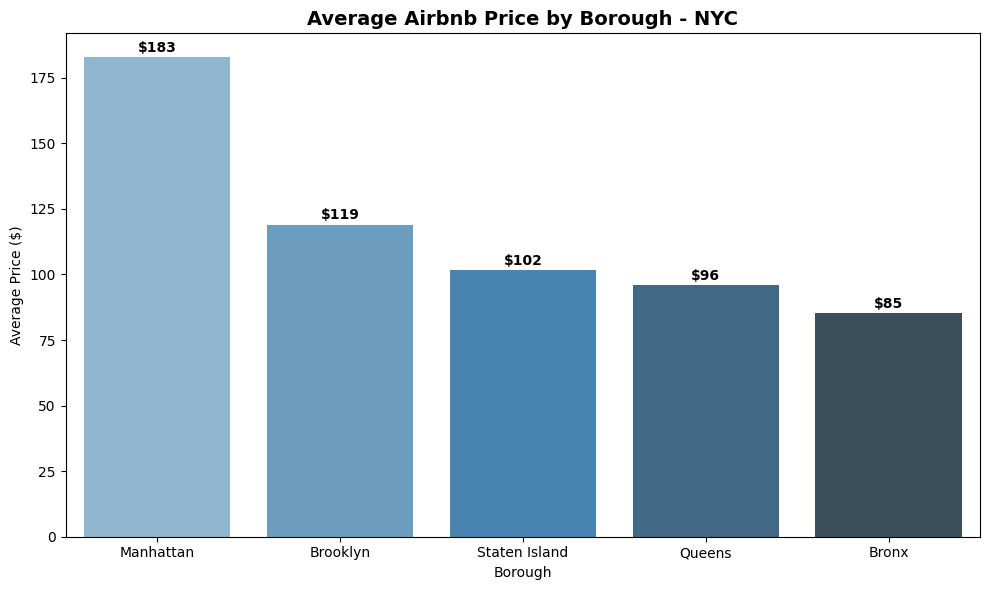

neighbourhood_group
Manhattan        182.78
Brooklyn         119.01
Staten Island    101.68
Queens            95.96
Bronx             85.36
Name: price, dtype: float64


In [6]:
borough_price = df.groupby('neighbourhood_group')['price'].mean().round(2).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=borough_price.index, y=borough_price.values, palette='Blues_d')
plt.title('Average Airbnb Price by Borough - NYC', fontsize=14, fontweight='bold')
plt.xlabel('Borough')
plt.ylabel('Average Price ($)')
for i, v in enumerate(borough_price.values):
    plt.text(i, v + 2, f'${v:.0f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('borough_price.png', dpi=150)
plt.show()

print(borough_price)

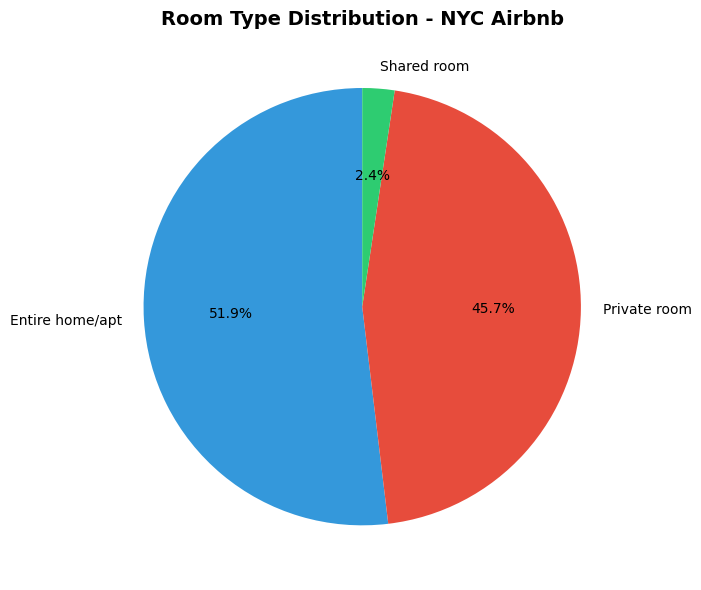

room_type
Entire home/apt    25298
Private room       22290
Shared room         1157
Name: count, dtype: int64


In [7]:
room_counts = df['room_type'].value_counts()

plt.figure(figsize=(8, 6))
plt.pie(room_counts.values, labels=room_counts.index, autopct='%1.1f%%',
        colors=['#3498db', '#e74c3c', '#2ecc71'], startangle=90)
plt.title('Room Type Distribution - NYC Airbnb', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('room_type.png', dpi=150)
plt.show()

print(room_counts)

/var/folders/17/zk_2gn5n5yl5y3873zlymd6h0000gn/T/ipykernel_3628/2357415796.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_neighbourhoods.values, y=top_neighbourhoods.index, palette='Reds_d')


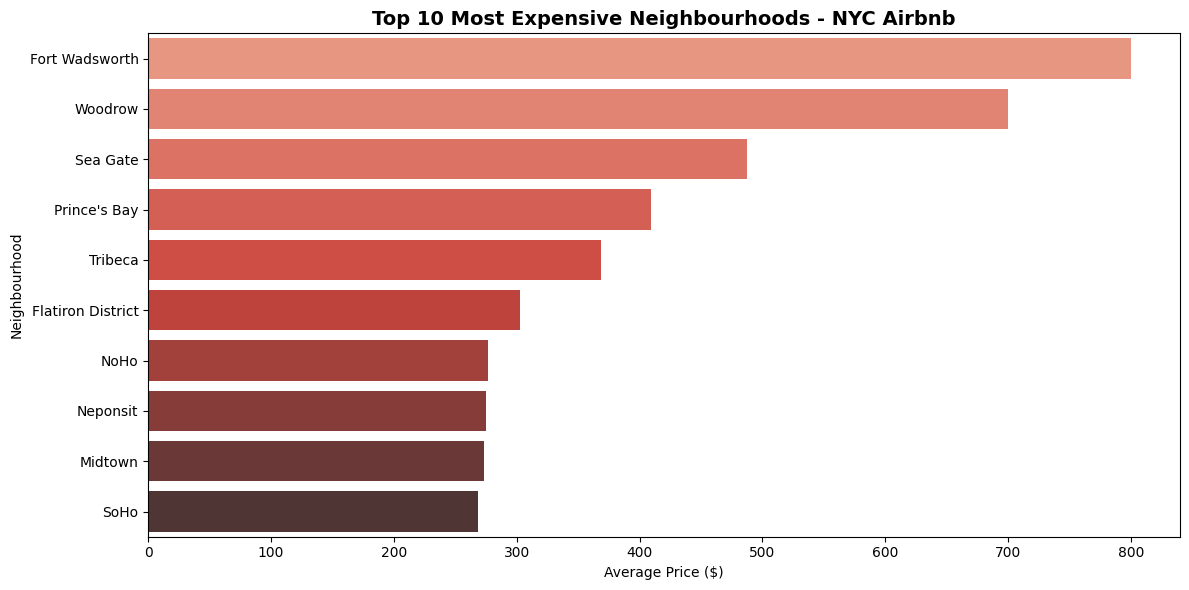

In [8]:
top_neighbourhoods = df.groupby('neighbourhood')['price'].mean().round(2)\
                       .sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_neighbourhoods.values, y=top_neighbourhoods.index, palette='Reds_d')
plt.title('Top 10 Most Expensive Neighbourhoods - NYC Airbnb', fontsize=14, fontweight='bold')
plt.xlabel('Average Price ($)')
plt.ylabel('Neighbourhood')
plt.tight_layout()
plt.savefig('top_neighbourhoods.png', dpi=150)
plt.show()

In [9]:
df.to_csv('airbnb_clean.csv', index=False)
print("Clean dataset saved as airbnb_clean.csv")
print("Final shape:", df.shape)
print("\nQuick summary:")
print(df[['neighbourhood_group', 'price', 'room_type', 'availability_pct']]\
      .groupby('neighbourhood_group').agg({'price': 'mean', 'availability_pct': 'mean'}).round(2))

Clean dataset saved as airbnb_clean.csv
Final shape: (48745, 19)

Quick summary:
                      price  availability_pct
neighbourhood_group                          
Bronx                 85.36             45.42
Brooklyn             119.01             27.43
Manhattan            182.78             30.59
Queens                95.96             39.56
Staten Island        101.68             54.60


In [10]:
import sqlite3

# Create database and load clean data
conn = sqlite3.connect('airbnb.db')
df.to_sql('listings', conn, if_exists='replace', index=False)
print("Database created successfully")
print("Table 'listings' loaded with", len(df), "rows")
conn.close()

Database created successfully
Table 'listings' loaded with 48745 rows


In [11]:
conn = sqlite3.connect('airbnb.db')

query1 = """
SELECT 
    neighbourhood_group AS borough,
    room_type,
    ROUND(AVG(price), 2) AS avg_price,
    COUNT(*) AS total_listings
FROM listings
GROUP BY neighbourhood_group, room_type
ORDER BY avg_price DESC;
"""

result1 = pd.read_sql_query(query1, conn)
print("Query 1: Average Price by Borough and Room Type")
print(result1.to_string())
conn.close()

Query 1: Average Price by Borough and Room Type
          borough        room_type  avg_price  total_listings
0       Manhattan  Entire home/apt     229.85           13117
1        Brooklyn  Entire home/apt     170.14            9534
2   Staten Island  Entire home/apt     146.27             175
3          Queens  Entire home/apt     143.94            2093
4           Bronx  Entire home/apt     127.51             379
5       Manhattan     Private room     110.94            7966
6       Manhattan      Shared room      88.98             480
7        Brooklyn     Private room      73.59           10116
8          Queens     Private room      68.24            3370
9           Bronx     Private room      63.15             650
10  Staten Island     Private room      62.29             188
11         Queens      Shared room      60.23             197
12          Bronx      Shared room      59.80              60
13  Staten Island      Shared room      57.44               9
14       Brooklyn     

In [12]:
conn = sqlite3.connect('airbnb.db')

query2 = """
SELECT 
    host_id,
    host_name,
    COUNT(*) AS total_listings,
    ROUND(AVG(price), 2) AS avg_price,
    SUM(number_of_reviews) AS total_reviews
FROM listings
GROUP BY host_id, host_name
ORDER BY total_listings DESC
LIMIT 10;
"""

result2 = pd.read_sql_query(query2, conn)
print("Query 2: Top 10 Hosts by Number of Listings")
print(result2.to_string())
conn.close()

Query 2: Top 10 Hosts by Number of Listings
     host_id          host_name  total_listings  avg_price  total_reviews
0  219517861       Sonder (NYC)             327     253.20           1281
1  107434423         Blueground             232     303.15             29
2   30283594               Kara             121     277.53             65
3  137358866             Kazuya             103      43.83             87
4   12243051             Sonder              96     213.03             43
5   16098958     Jeremy & Laura              96     208.96            138
6   61391963  Corporate Housing              91     146.24            417
7   22541573                Ken              87     215.44             55
8  200380610            Pranjal              65     290.23              1
9    1475015               Mike              52     103.08            162


In [13]:
conn = sqlite3.connect('airbnb.db')

query3 = """
SELECT 
    neighbourhood_group AS borough,
    ROUND(AVG(availability_pct), 2) AS avg_availability_pct,
    ROUND(AVG(price), 2) AS avg_price,
    COUNT(*) AS total_listings,
    SUM(CASE WHEN availability_365 = 0 THEN 1 ELSE 0 END) AS fully_booked_listings
FROM listings
GROUP BY neighbourhood_group
HAVING avg_availability_pct > 0
ORDER BY avg_availability_pct DESC;
"""

result3 = pd.read_sql_query(query3, conn)
print("Query 3: Borough Availability and Pricing Analysis")
print(result3.to_string())
conn.close()

Query 3: Borough Availability and Pricing Analysis
         borough  avg_availability_pct  avg_price  total_listings  fully_booked_listings
0  Staten Island                 54.60     101.68             372                     42
1          Bronx                 45.42      85.36            1089                    177
2         Queens                 39.56      95.96            5660                   1366
3      Manhattan                 30.59     182.78           21563                   8075
4       Brooklyn                 27.43     119.01           20061                   7832


In [14]:
conn = sqlite3.connect('airbnb.db')

query4 = """
SELECT 
    neighbourhood_group AS borough,
    price,
    NTILE(4) OVER (PARTITION BY neighbourhood_group ORDER BY price) AS price_quartile,
    ROUND(AVG(price) OVER (PARTITION BY neighbourhood_group), 2) AS borough_avg_price,
    ROUND(AVG(price) OVER (), 2) AS overall_avg_price
FROM listings
ORDER BY neighbourhood_group, price;
"""

result4 = pd.read_sql_query(query4, conn)
print("Query 4: Price Quartiles by Borough (Window Function)")
print(result4.head(20).to_string())
conn.close()

Query 4: Price Quartiles by Borough (Window Function)
   borough  price  price_quartile  borough_avg_price  overall_avg_price
0    Bronx     10               1              85.36             143.66
1    Bronx     20               1              85.36             143.66
2    Bronx     20               1              85.36             143.66
3    Bronx     20               1              85.36             143.66
4    Bronx     20               1              85.36             143.66
5    Bronx     20               1              85.36             143.66
6    Bronx     20               1              85.36             143.66
7    Bronx     21               1              85.36             143.66
8    Bronx     22               1              85.36             143.66
9    Bronx     22               1              85.36             143.66
10   Bronx     23               1              85.36             143.66
11   Bronx     24               1              85.36             143.66
12   Bronx

In [15]:
conn = sqlite3.connect('airbnb.db')

query5 = """
WITH host_stats AS (
    SELECT 
        host_id,
        host_name,
        neighbourhood_group AS borough,
        COUNT(*) AS listing_count,
        ROUND(AVG(price), 2) AS avg_price,
        SUM(number_of_reviews) AS total_reviews
    FROM listings
    GROUP BY host_id, host_name, neighbourhood_group
),
borough_stats AS (
    SELECT
        borough,
        COUNT(DISTINCT host_id) AS total_hosts,
        SUM(listing_count) AS total_listings,
        ROUND(AVG(avg_price), 2) AS borough_avg_price
    FROM host_stats
    GROUP BY borough
)
SELECT 
    h.borough,
    h.host_name,
    h.listing_count,
    h.avg_price,
    b.total_hosts,
    b.total_listings,
    ROUND(CAST(h.listing_count AS FLOAT) / b.total_listings * 100, 2) AS pct_of_borough_listings
FROM host_stats h
JOIN borough_stats b ON h.borough = b.borough
WHERE h.listing_count > 5
ORDER BY h.listing_count DESC
LIMIT 20;
"""

result5 = pd.read_sql_query(query5, conn)
print("Query 5: Host Concentration Analysis (CTE)")
print(result5.to_string())
conn.close()

Query 5: Host Concentration Analysis (CTE)
      borough          host_name  listing_count  avg_price  total_hosts  total_listings  pct_of_borough_listings
0   Manhattan       Sonder (NYC)            327     253.20        16509           21563                     1.52
1   Manhattan         Blueground            230     303.22        16509           21563                     1.07
2   Manhattan               Kara            121     277.53        16509           21563                     0.56
3   Manhattan             Sonder             96     213.03        16509           21563                     0.45
4   Manhattan     Jeremy & Laura             96     208.96        16509           21563                     0.45
5   Manhattan  Corporate Housing             91     146.24        16509           21563                     0.42
6   Manhattan                Ken             86     215.59        16509           21563                     0.40
7      Queens             Kazuya             79      